## Import libraries

In [5]:
import SimpleITK as sitk # type: ignore
import os
import numpy as np # type: ignore
import pandas as pd # type: ignore
import matplotlib.pyplot as plt # type: ignore
import shutil # type: ignore
import seaborn as sns # type: ignore
import tensorflow as tf # type: ignore
from skimage.metrics import peak_signal_noise_ratio as psnr # type: ignore
from skimage.metrics import structural_similarity as ssim # type: ignore
from sklearn.preprocessing import MinMaxScaler # type: ignore
from sklearn.preprocessing import StandardScaler # type: ignore
from sklearn.preprocessing import MaxAbsScaler # type: ignore
from sklearn.preprocessing import RobustScaler # type: ignore

2025-03-16 19:06:58.651698: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1742139418.668609   47705 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1742139418.674243   47705 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-16 19:06:58.691147: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Load Datasets

In [6]:
df_adc = pd.read_csv("../Part2/df_adc.csv").set_index("Study Instance UID")
df_hbv = pd.read_csv("../Part2/df_hbv.csv").set_index("Study Instance_UID")
df_cor = pd.read_csv("../Part2/df_cor.csv").set_index("Study Instance UID")
df_t2w = pd.read_csv("../Part2/df_t2w.csv").set_index("Study Instance UID")
df_sag = pd.read_csv("../Part2/df_sag.csv").set_index("Study Instance UID")

## Edge detection

### Sobel Edge detection

In [17]:
def sobel_edge(df):
    image = sitk.ReadImage(df["path"].iloc[1])
    medain_filter = sitk.MedianImageFilter()
    medain_filter.SetRadius(3)
    medain_image = medain_filter.Execute(image)
    sobel_filter = sitk.SobelEdgeDetectionImageFilter()
    edged_image = sobel_filter.Execute(medain_image)
    edged_image_arr = sitk.GetArrayFromImage(edged_image)

    plt.figure(figsize=(5, 5))
    plt.imshow(edged_image_arr[10], cmap="gray")
    plt.title(f"sobel Edge detection")
    plt.tight_layout()
    plt.show()

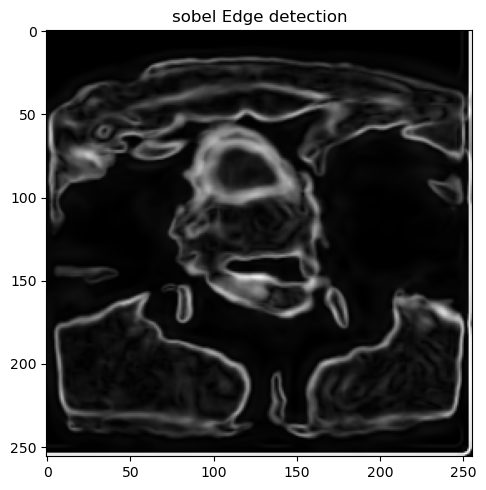

In [18]:
sobel_edge(df_adc)

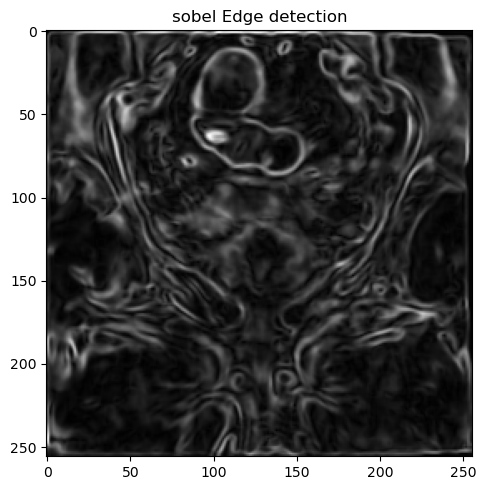

In [16]:
sobel_edge(df_cor)

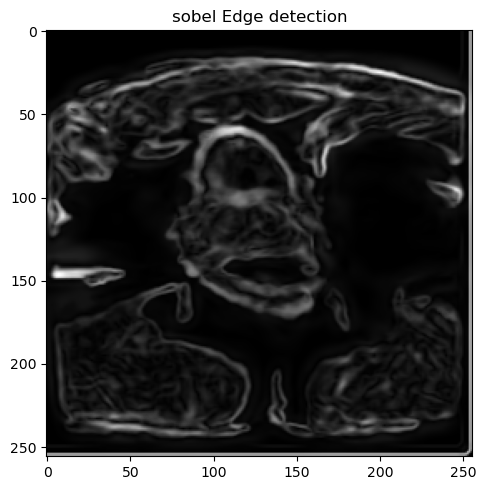

In [11]:
sobel_edge(df_hbv)

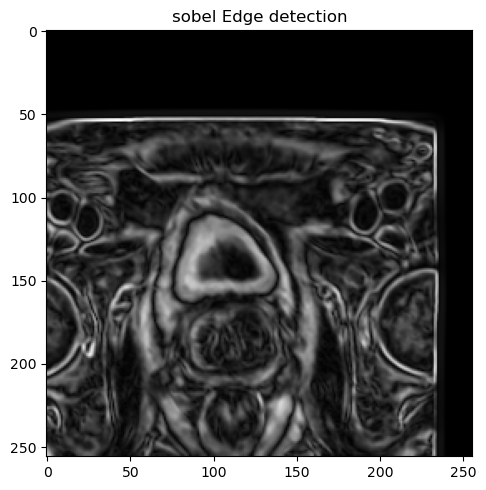

In [35]:
sobel_edge(df_t2w)

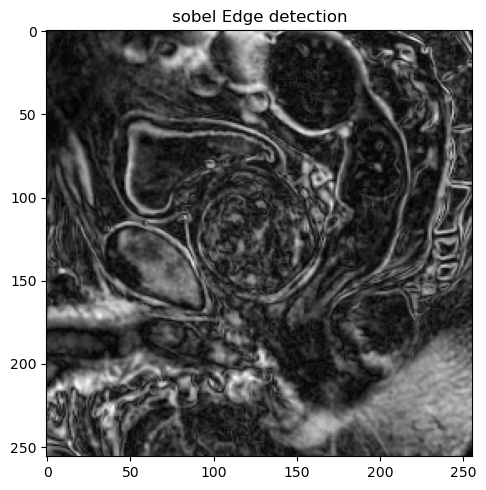

In [18]:
sobel_edge(df_sag)

### Canny Edge detection

In [43]:
def canny_edge(df):
    image = sitk.ReadImage(df["path"].iloc[5])
    canny_filter = sitk.CannyEdgeDetectionImageFilter()
    edged_image = canny_filter.Execute(image)
    edged_image_arr = sitk.GetArrayFromImage(edged_image)

    plt.figure(figsize=(5, 5))
    plt.imshow(edged_image_arr[10], cmap="gray")
    plt.title(f"canny Edge detection")
    plt.tight_layout()
    plt.show()

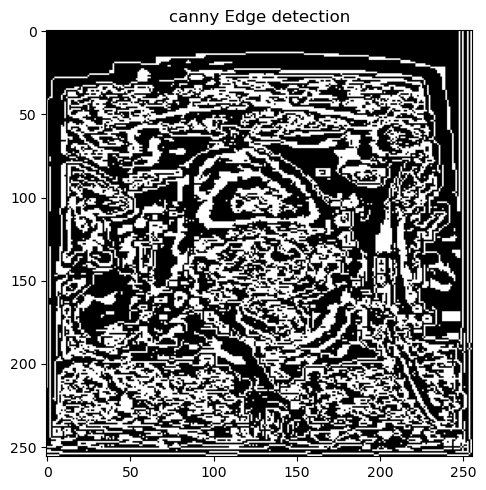

In [44]:
canny_edge(df_adc)